Kawasaki Quantum Summer Camp 2024

# 量子ハードウェア


Kifumi Numata, IBM Quantum (Jul 31, 2024)

Google Colab で行う場合は、次のセルの「#」を削除して実行します。

In [47]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer qiskit[visualization]

qBraid で行う場合は、右上の「Python 3[Default]」をクリックして「Python 3[QDC24]」を選択し、次のセルの「#」を削除して実行したあと、上部の「Kernel」→「Restart Kernel...」からカーネルをリスタートしてください。

In [ ]:
#!pip install pylatexenc
#!sudo apt install graphviz --yes
#!pip install seaborn

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import rustworkx as rx
import statistics

from qiskit_ibm_runtime import QiskitRuntimeService

### バックエンドの情報をみる

Qiskitは、量子デバイスに関する情報を取得するためのAPI ([アプリケーション・プログラミング・インタフェース](https://ja.wikipedia.org/wiki/%E3%82%A2%E3%83%97%E3%83%AA%E3%82%B1%E3%83%BC%E3%82%B7%E3%83%A7%E3%83%B3%E3%83%97%E3%83%AD%E3%82%B0%E3%83%A9%E3%83%9F%E3%83%B3%E3%82%B0%E3%82%A4%E3%83%B3%E3%82%BF%E3%83%95%E3%82%A7%E3%83%BC%E3%82%B9))を提供しています。デバイスとのインターフェースである、Backend命令を使用を使って、IBM Quantum Platformの[デバイスカード](https://quantum.ibm.com/services/resources)に表示される情報の一部を取得してみましょう。以下では、"ibm_kyiv" を選びます。

In [51]:
# Google Colab で行う場合は、次の「#」を削除して、https://quantum.ibm.com/ の API Tokenをコピペして、実行します。
QiskitRuntimeService.save_account(channel='ibm_quantum', overwrite=True, instance='utokyo-kawasaki/internal/ipmu-sr', token='1a6ef0257e235df597c0d68e941f0a56d8147c504f544b5fa96f137e148f55a903657fe8c086b1d8ad4f4ef1cff51cd73c507daab91daaba72109e2e15c7a420')

service = QiskitRuntimeService()
backend = service.backend("ibm_kawasaki")

まず、デバイスに関する基本的な情報から見てみます。

In [ ]:
print(
    f"""
{backend.name}, {backend.num_qubits} qubits
processor type = {backend.processor_type}
basis gates = {backend.basis_gates}
""")

#### 演習 1

別のデバイス "ibm_sherbrooke" の基本情報を取得してみてください。

In [52]:
an_eagle = service.backend("ibm_sherbrooke")

# ここにコードを入れます
print(
    f"""



""")

QiskitBackendNotFoundError: "Backend ibm_sherbrooke is not in utokyo-kawasaki/internal/ipmu-sr. Please try a different instance. ibm_sherbrooke is in the following instances you have access to: ['ibm-q/open/main']"

### カップリング・マップ

次にデバイスのカップリング・マップを表示します。ご覧のように、ノード（頂点）が量子ビットで、番号が振られています。エッジ（辺）は、2量子ビットのエンタングルゲートが直接適用できるペアを示しています。このトポロジーはヘビーヘックス格子と呼ばれます。


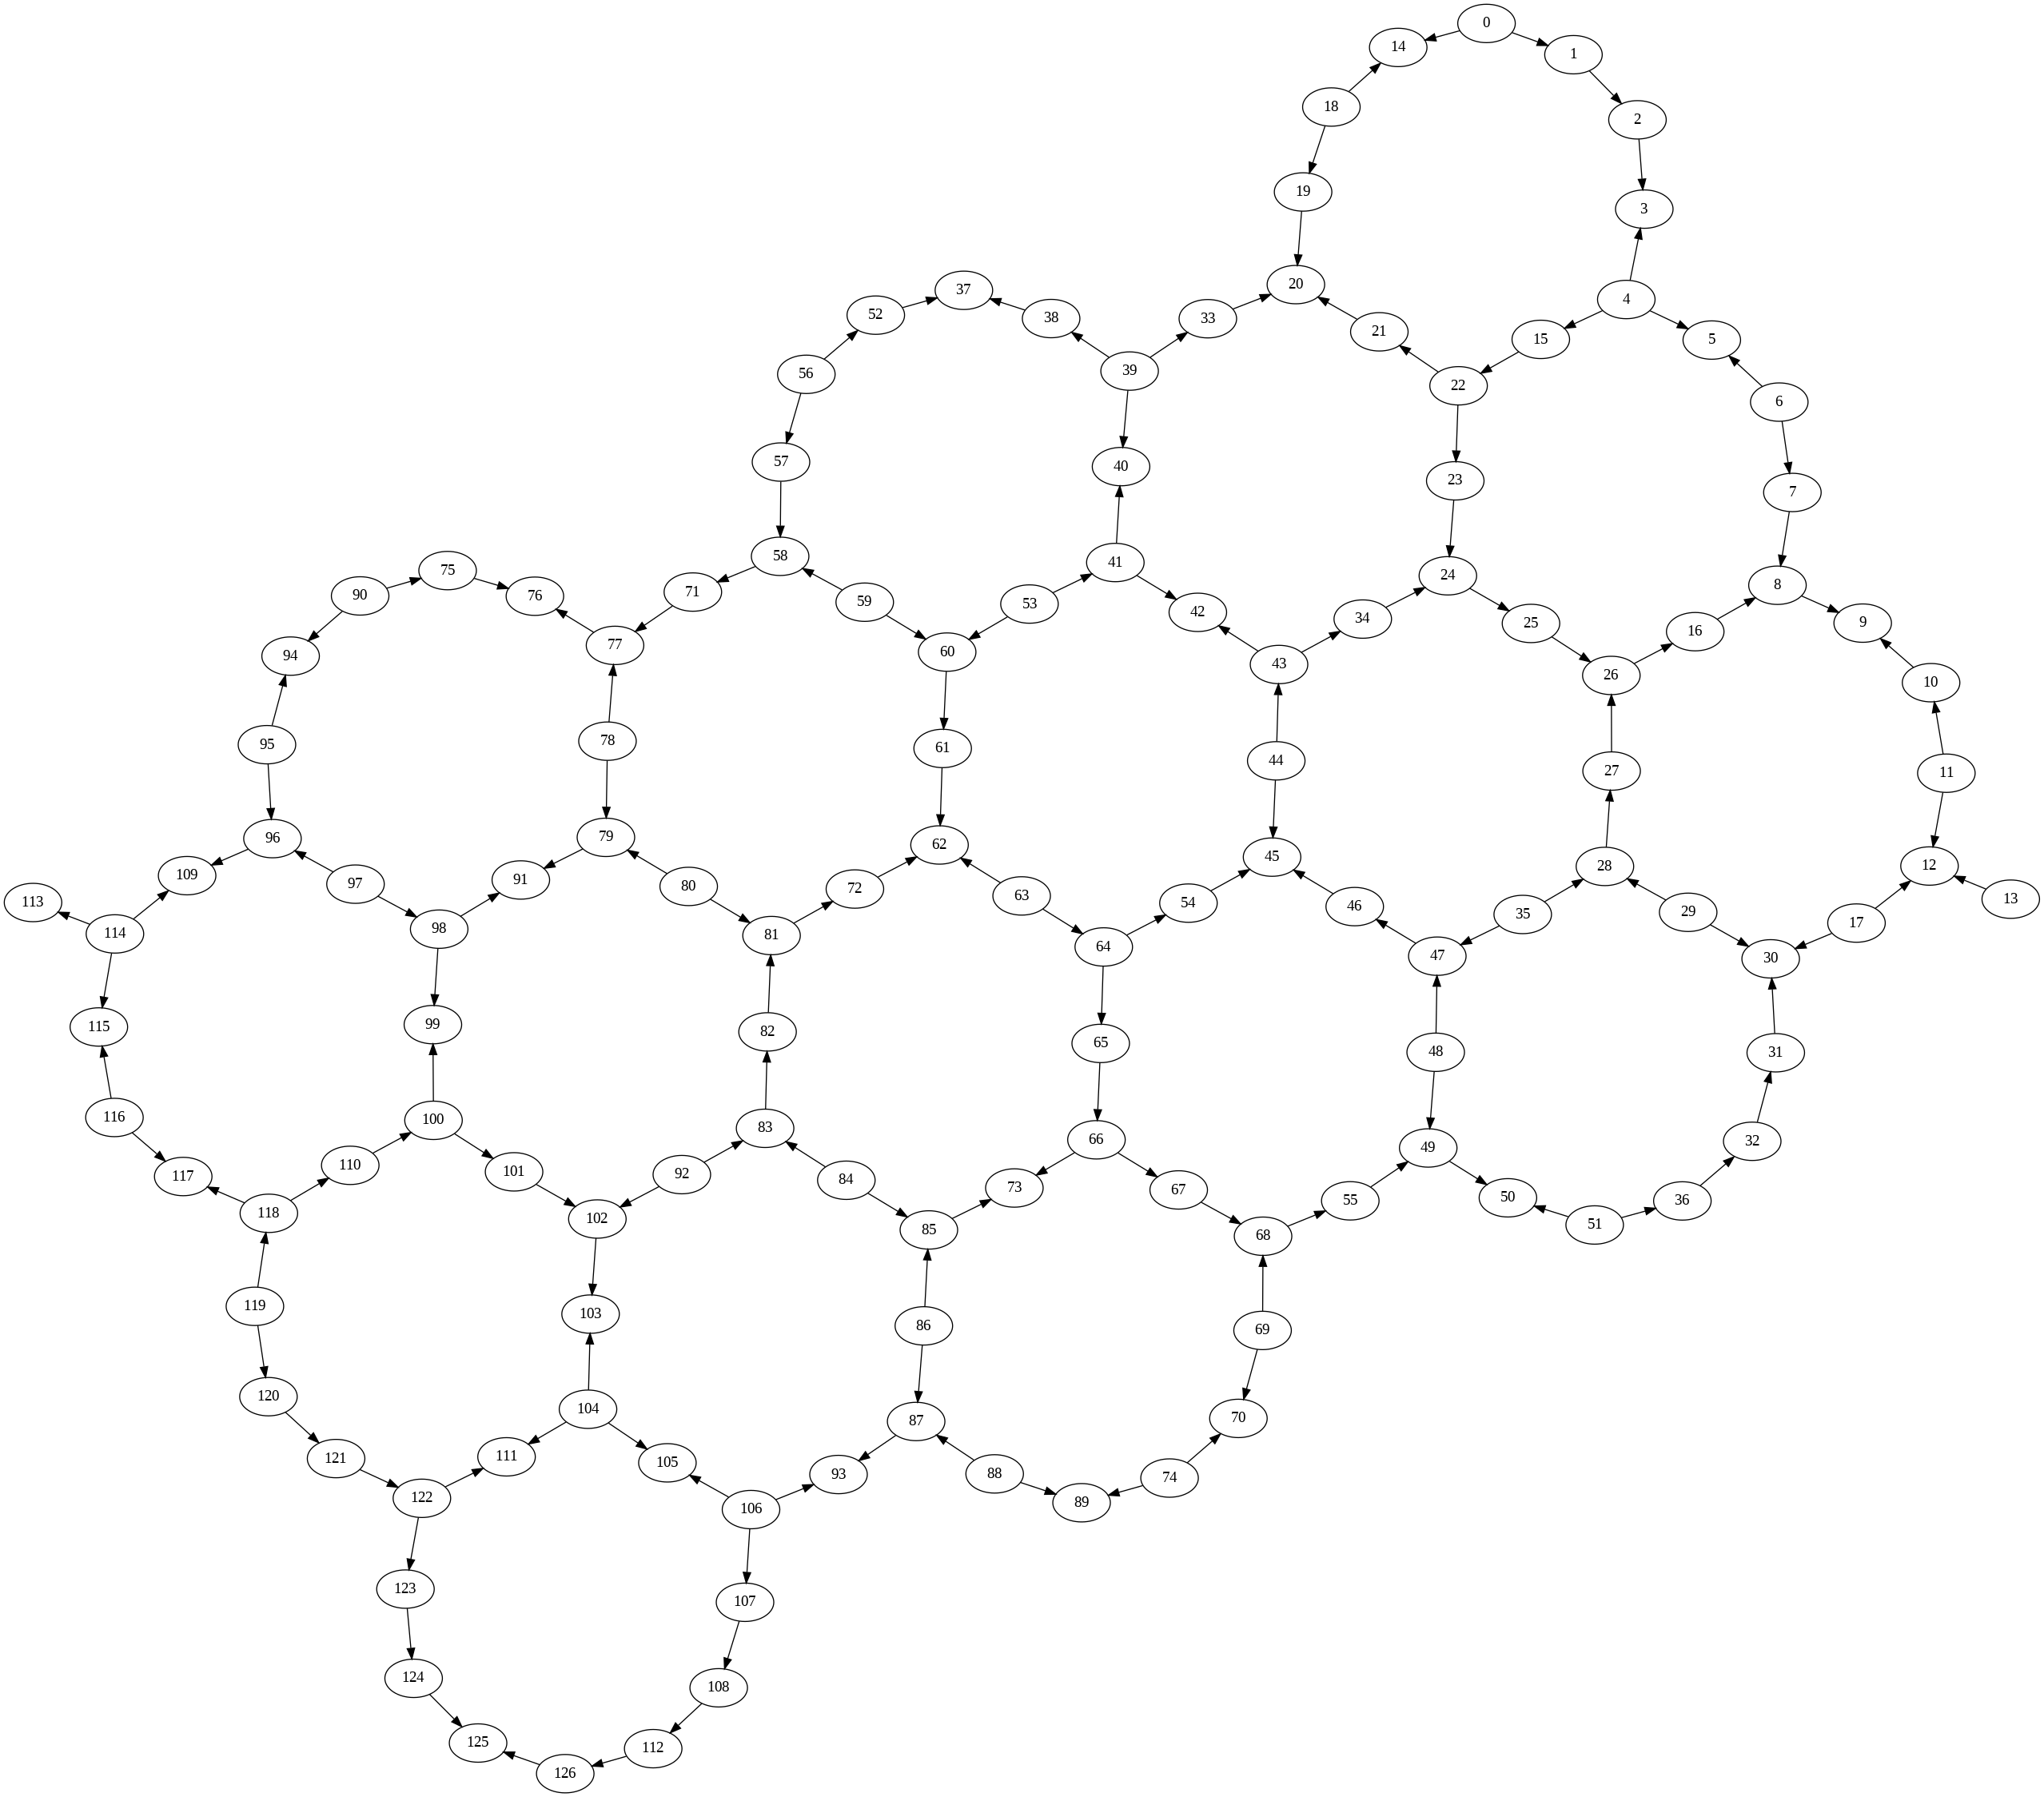

In [53]:
backend.coupling_map.draw()

### 量子ビットの特性

Eagle デバイスには127個の量子ビットがあります。そのいくつかの特性(Properties)を`qubit_properties`を使って、求めてみましょう。0~4までの5量子ビットのみ表示します。

In [54]:
for qn in range(backend.num_qubits):
    if (qn>=5):
        break
    print(f"{qn}: {backend.qubit_properties(qn)}")

0: QubitProperties(t1=0.00012052464193538445, t2=0.00015427829769832768, frequency=5243551523.972542)
1: QubitProperties(t1=0.0002388255207472013, t2=0.0003020226068071324, frequency=5189775231.2005205)
2: QubitProperties(t1=0.00025914377158044475, t2=0.0003934514881665349, frequency=5081333859.960893)
3: QubitProperties(t1=0.0001550196227147032, t2=0.0001647548232632613, frequency=5000416909.924594)
4: QubitProperties(t1=0.000221959702752914, t2=0.00010385808346005254, frequency=5060646989.064617)


各量子ビットごとのT1時間、T2時間、共鳴周波数が確認できました。    
量子ビットのT1時間の[中央値](https://ja.wikipedia.org/wiki/%E4%B8%AD%E5%A4%AE%E5%80%A4) (Median)を計算してみましょう。[IBM Quantum Platfrom](https://quantum.ibm.com/services/resources)のデバイスの結果と比較してみてください。

In [55]:
t1s = [backend.qubit_properties(qq).t1 for qq in range(backend.num_qubits)] #t1をリスト化
t1_m = statistics.median(t1s)*10**6 #中央値を求め、10の６乗をかけて単位をμsに。

print(f'Median T1: {t1_m:.2f}μs') #有効数字小数点以下２桁

Median T1: 197.83μs


#### 演習 2

量子ビットのT2時間の中央値を計算してください。

In [57]:
t2s = [backend.qubit_properties(qq).t2 for qq in range(backend.num_qubits)]  #t2をリスト化
t2_m = statistics.median(t2s)*10**6 #中央値を求め、10の６乗をかけて単位をμsに。

print(f'Median T2: {t2_m:.2f}μs') #有効数字小数点以下２桁

Median T2: 159.36μs


###  ゲートエラーと読み出しエラー

次にゲートエラーについて見てみます。まずはじめに、backendのtargetのデータ構造を調べます。演算の名前をキーとする[辞書](https://utokyo-ipp.github.io/3/3-1.html)になっています。

In [58]:
target = backend.target
target.keys()

dict_keys(['id', 'x', 'reset', 'delay', 'rz', 'sx', 'measure', 'for_loop', 'if_else', 'switch_case', 'ecr'])

その値も辞書です。'sx' 演算の値（辞書）の項目を5個目まで見てみましょう。

In [59]:
for i, qq in enumerate(target['sx']):
    if (i>=5):
        break
    print(i, qq, target['sx'][qq])

0 (0,) InstructionProperties(duration=5.333333333333333e-08, error=0.0002587072105900676, calibration=PulseQobj)
1 (1,) InstructionProperties(duration=5.333333333333333e-08, error=0.00012817956323430587, calibration=PulseQobj)
2 (2,) InstructionProperties(duration=5.333333333333333e-08, error=0.0001322618306570045, calibration=PulseQobj)
3 (3,) InstructionProperties(duration=5.333333333333333e-08, error=0.00024226227151380515, calibration=PulseQobj)
4 (4,) InstructionProperties(duration=5.333333333333333e-08, error=0.00016421506488806695, calibration=PulseQobj)


演算の持続時間(duration)、エラー率、キャリブレーションの形式をみることができました。

'ecr' 演算と 'measure' 演算についても同じようにみてみましょう。

In [60]:
for i, edge in enumerate(target['ecr']):
    if (i>=5):
        break
    print(i, edge, target['ecr'][edge])

0 (0, 1) InstructionProperties(duration=5.866666666666666e-07, error=0.006374112285701339, calibration=PulseQobj)
1 (0, 14) InstructionProperties(duration=5.866666666666666e-07, error=0.008039017979446728, calibration=PulseQobj)
2 (1, 2) InstructionProperties(duration=5.866666666666666e-07, error=0.004407965495637267, calibration=PulseQobj)
3 (2, 3) InstructionProperties(duration=5.866666666666666e-07, error=0.006232611496272855, calibration=PulseQobj)
4 (4, 3) InstructionProperties(duration=5.866666666666666e-07, error=0.007248208331053774, calibration=PulseQobj)


In [61]:
for i, qq in enumerate(target['measure']):
    if (i>=5):
        break
    print(i, qq, target['measure'][qq])

0 (0,) InstructionProperties(duration=1.112888888888889e-06, error=0.027587890625, calibration=PulseQobj)
1 (1,) InstructionProperties(duration=1.112888888888889e-06, error=0.01611328125, calibration=PulseQobj)
2 (2,) InstructionProperties(duration=1.112888888888889e-06, error=0.008056640625, calibration=PulseQobj)
3 (3,) InstructionProperties(duration=1.112888888888889e-06, error=0.0107421875, calibration=PulseQobj)
4 (4,) InstructionProperties(duration=1.112888888888889e-06, error=0.025146484375, calibration=PulseQobj)


それそれの error の値から、読み出し(measure)エラーは2量子ビット演算(ecr)のエラーよりも大きくなる傾向があり、2量子ビット演算(ecr)のエラーは、1量子ビット演算(sx)のエラーよりも大きくなる傾向があることが分かります。

データ構造を理解したところで、'sx' ゲートと 'ecr' ゲートのエラーの中央値を計算しましょう。ここでも、[IBM Quantum Platfrom](https://quantum.ibm.com/services/resources) のデバイスで示された結果と比較してください。

In [62]:
sx_errors = [inst_prop.error for inst_prop in target['sx'].values()] #sxゲートエラーをリスト化
sx_errors_m = statistics.median(sx_errors) #中央値を計算

print(f'Median SX error: {sx_errors_m:.3e}μs') #有効数字 小数点以下指数表示で3桁

Median SX error: 2.473e-04μs


In [63]:
ecr_errors = [inst_prop.error for inst_prop in target['ecr'].values()] #ecrゲートエラーをリスト化
ecr_errors_m = statistics.median(ecr_errors) #中央値を計算

print(f'Median ECR error: {ecr_errors_m:.3e}μs') #有効数字 小数点以下指数表示で3桁

Median ECR error: 8.917e-03μs


#### 演習 3

デバイスの読み出しエラーの中央値を計算してください。

In [64]:
# コードをここに書いてください
meas_errors =  [inst_prop.error for inst_prop in target['measure'].values()]   #measureエラーをリスト化
meas_errors_m = statistics.median(meas_errors)  #中央値を計算

print(f'Median readout error: {meas_errors_m:.3e}') #有効数字 小数点以下指数表示で3桁

Median readout error: 1.831e-02


### パルス形状
次に、InstructionPropertiesのcalibration（較正）の属性を見てみましょう。実は、命令のパルス形状を得ることができます。Qubit 0の 'sx' 命令をチェックしてみましょう。


Schedule((0, Play(Drag(duration=240, sigma=60, beta=-3.858536098056384, amp=0.08837533069346735, angle=0.013667704842523687, name='X90p_d0'), DriveChannel(0), name='X90p_d0')), name="sx")


<ipython-input-66-96566ab700ed>:1: DeprecationWarning: The property ``qiskit.transpiler.target.InstructionProperties.calibration`` is deprecated as of Qiskit 1.3. It will be removed in Qiskit 2.0. The entire Qiskit Pulse package is being deprecated and will be moved to the Qiskit Dynamics repository: https://github.com/qiskit-community/qiskit-dynamics. Note that once removed, ``qiskit.transpiler.target.InstructionProperties.calibration`` will have no alternative in Qiskit.
  print(backend.target["sx"][(0, )].calibration)
<ipython-input-66-96566ab700ed>:2: DeprecationWarning: The property ``qiskit.transpiler.target.InstructionProperties.calibration`` is deprecated as of Qiskit 1.3. It will be removed in Qiskit 2.0. The entire Qiskit Pulse package is being deprecated and will be moved to the Qiskit Dynamics repository: https://github.com/qiskit-community/qiskit-dynamics. Note that once removed, ``qiskit.transpiler.target.InstructionProperties.calibration`` will have no alternative in Qis

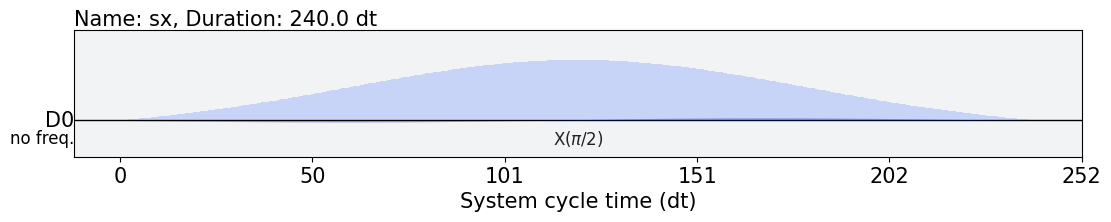

In [66]:
print(backend.target["sx"][(0, )].calibration)
backend.target["sx"][(0, )].calibration.draw()

<ipython-input-68-295bad63a4d1>:1: DeprecationWarning: The property ``qiskit.transpiler.target.InstructionProperties.calibration`` is deprecated as of Qiskit 1.3. It will be removed in Qiskit 2.0. The entire Qiskit Pulse package is being deprecated and will be moved to the Qiskit Dynamics repository: https://github.com/qiskit-community/qiskit-dynamics. Note that once removed, ``qiskit.transpiler.target.InstructionProperties.calibration`` will have no alternative in Qiskit.
  backend.target["rz"][(0, )].calibration.draw()


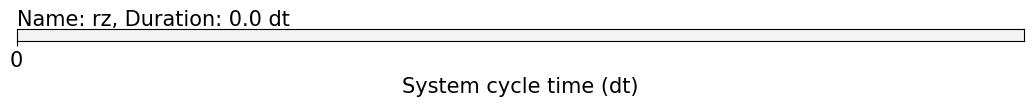

In [68]:
backend.target["rz"][(0, )].calibration.draw()

ここでみてきたことがらは、BackendとTargetでできることのほんの一例に過ぎません。

さらに、[Qiskit Experiment](https://qiskit-extensions.github.io/qiskit-experiments/) を使えば、Qiskitを通して特性評価やキャリブレーション実験を行うことができますが、今回は扱いません。

## 付録

Qiskit は、可視化機能が充実していることでも人気があります。回路の可視化、状態や分布の可視化、ターゲットデバイスの可視化ができます。回路の可視化、状態や分布の可視化は、このノートブックですでに使ってみたので、ターゲットデバイスの可視化の機能を以下で使ってみましょう。

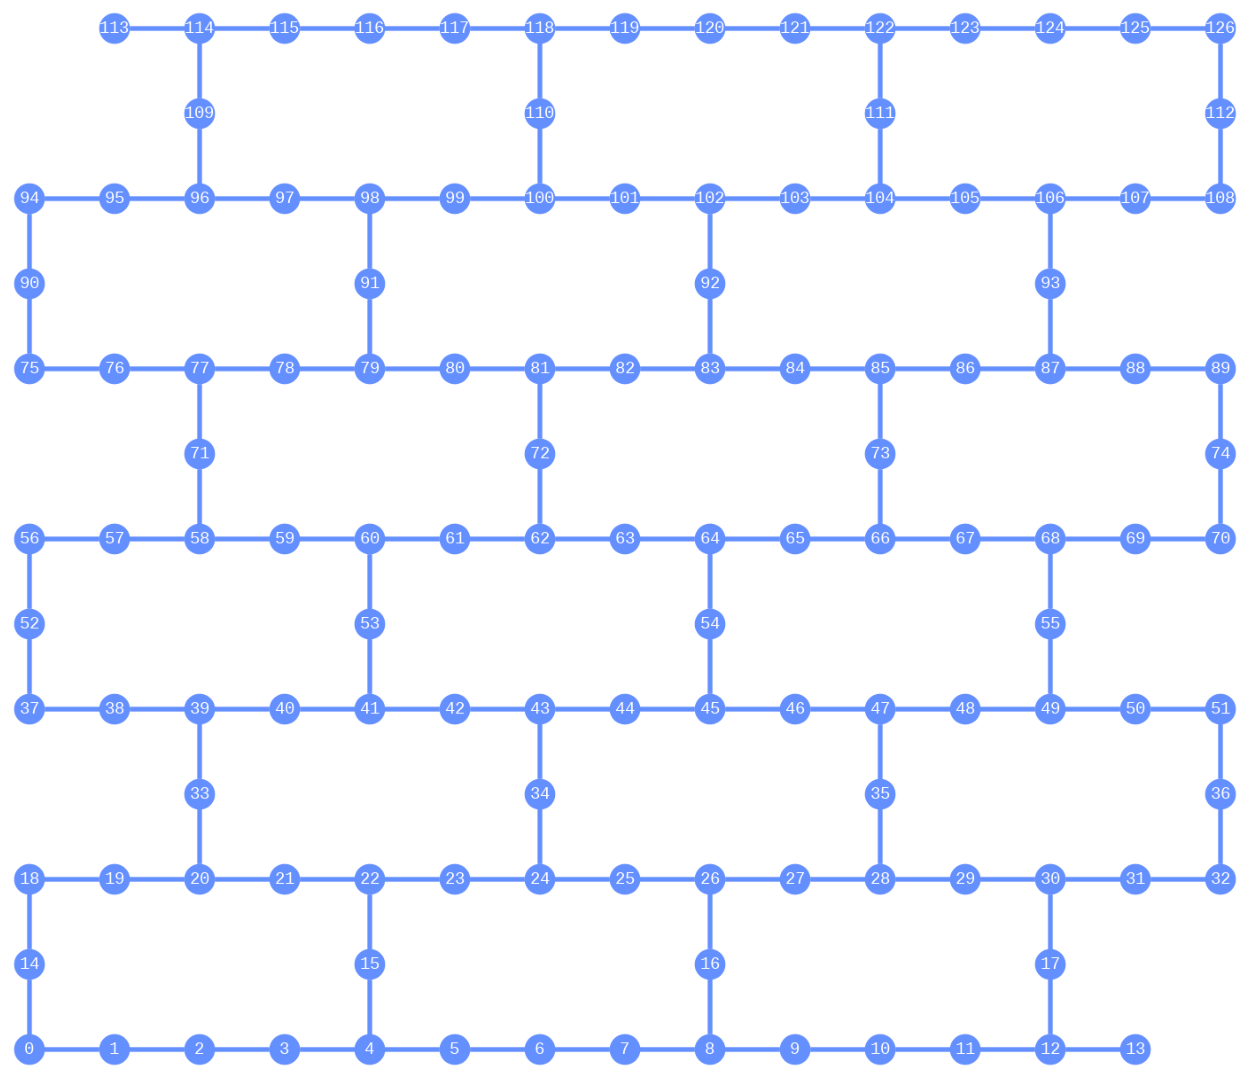

In [69]:
from qiskit.visualization import plot_gate_map

plot_gate_map(backend, font_size=14)

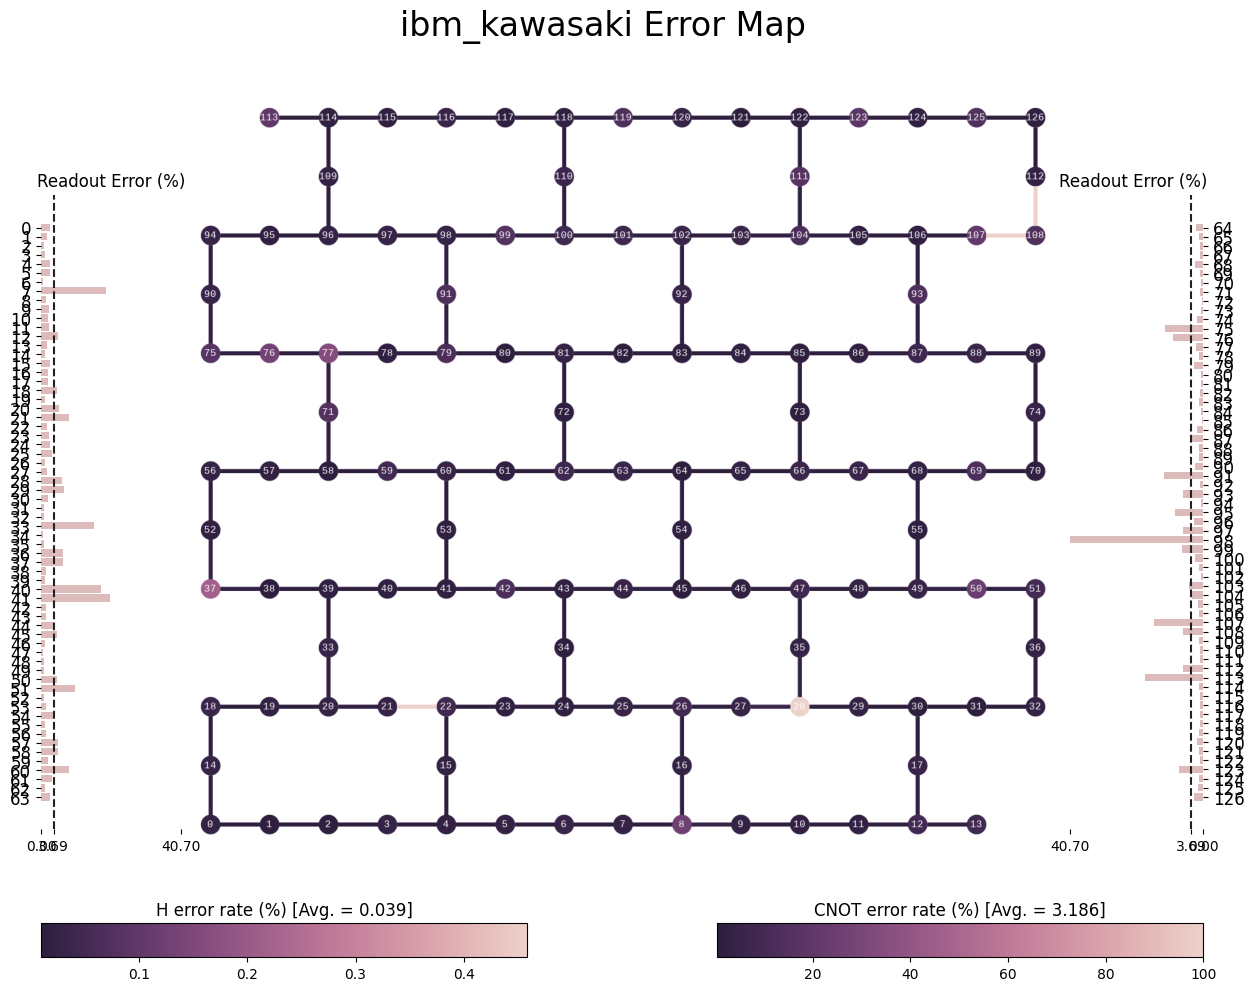

In [70]:
from qiskit.visualization import plot_error_map

plot_error_map(backend)

In [ ]:
import qiskit
qiskit.__version__